In [1]:
import os

In [2]:
%pwd

'/content'

In [6]:
path= "/content/drive/MyDrive/SDC/Data/Humidity_Temperature//"
os.chdir(path)
%pwd

'/content/drive/MyDrive/SDC/Data/Humidity_Temperature'

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
os.listdir()

['Polynomial Feature Model 03.png',
 'Polynomial Feature Model 01.png',
 'Data Mining Process 02.png',
 'Polynomial Feature Model 02.png',
 'Residual.png',
 'Data Mining Process 01.png',
 'Humidity_Temp_Prediction.csv',
 'hour vs temp Plotting.jpg',
 'month vs temp Plotting.jpg',
 'minute vs temp Plotting.jpg',
 'Humidity_Temp_Prediction.xlsx']

In [8]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Image Display
from IPython.display import display, Image
# Ignore Warning (Warning statements may be replaced/ changed in the future)
import warnings
warnings.filterwarnings("ignore")

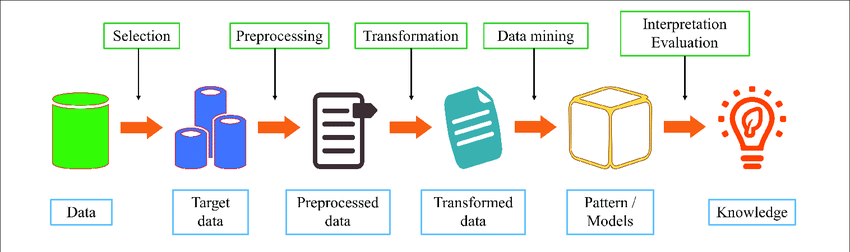

In [9]:
display(Image(filename="Data Mining Process 01.png"))

In [10]:
data = pd.read_csv("Humidity_Temp_Prediction.csv", delimiter = ";")
display(data.head())
display(data.shape)
display(data.info())


,id,temp,humidity,date_time
0,9197,21,20,2016-08-17 00:00:01
1,9198,21,20,2016-08-17 00:01:01
2,9199,21,20,2016-08-17 00:02:01
3,9200,21,20,2016-08-17 00:03:01
4,9201,21,20,2016-08-17 00:04:01


(619999, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619999 entries, 0 to 619998
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         619999 non-null  int64 
 1   temp       619999 non-null  int64 
 2   humidity   619999 non-null  int64 
 3   date_time  619999 non-null  object
dtypes: int64(3), object(1)
memory usage: 18.9+ MB


None

In [11]:
data['date_time'] = pd.to_datetime(data['date_time'], format="%Y-%m-%d %H:%M:%S")
# Ex1: data['date_time']= data['data_time'].astype('datetime64')
# Ex2: datetime.strptime ???
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619999 entries, 0 to 619998
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         619999 non-null  int64         
 1   temp       619999 non-null  int64         
 2   humidity   619999 non-null  int64         
 3   date_time  619999 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 18.9 MB


In [12]:
data['date_time']
print(type(data['date_time']))

<class 'pandas.core.series.Series'>


In [13]:
data['hour'] = data['date_time'].dt.hour
data['minute'] = data['date_time'].dt.minute
data['Date_Of_Week'] = data['date_time'].dt.day_name()
data['month'] = data['date_time'].dt.month
data['minute']= data['minute'] + data['hour']*60
data.head()
data.drop('id',inplace=True, axis=1)
data.head()

,temp,humidity,date_time,hour,minute,Date_Of_Week,month
0,21,20,2016-08-17 00:00:01,0,0,Wednesday,8
1,21,20,2016-08-17 00:01:01,0,1,Wednesday,8
2,21,20,2016-08-17 00:02:01,0,2,Wednesday,8
3,21,20,2016-08-17 00:03:01,0,3,Wednesday,8
4,21,20,2016-08-17 00:04:01,0,4,Wednesday,8


In [14]:
NumDescripticeStats=data.describe(include = [np.number])
CatDescripticeStats=data.describe(exclude = [np.number])
display(NumDescripticeStats)
display(CatDescripticeStats)

,temp,humidity,hour,minute,month
count,619999.000000,619999.000000,619999.000000,619999.000000,619999.000000
mean,19.365405,41.340391,11.436893,715.723067,7.460789
std,1.523185,32.418998,6.946960,417.192832,3.360717
min,15.000000,16.000000,0.000000,0.000000,1.000000
25%,18.000000,20.000000,5.000000,354.000000,5.000000
50%,19.000000,21.000000,11.000000,711.000000,8.000000
75%,20.000000,95.000000,17.000000,1079.000000,10.000000
max,28.000000,95.000000,23.000000,1439.000000,12.000000


,date_time,Date_Of_Week
count,619999,619999
unique,NaN,7
top,NaN,Thursday
freq,NaN,91761
mean,2017-04-18 03:40:06.135869440,NaN
min,2016-08-17 00:00:01,NaN
25%,2016-12-12 05:07:31,NaN
50%,2017-04-20 14:24:02,NaN
75%,2017-08-22 00:26:31.500000,NaN
max,2017-12-17 03:17:02,NaN


,hour,temp
0,0,19.118611
1,1,19.083789
2,2,19.074765
3,3,19.102233
4,4,19.135009
5,5,19.143692
6,6,19.167604
7,7,19.286310
8,8,19.410452
9,9,19.469362


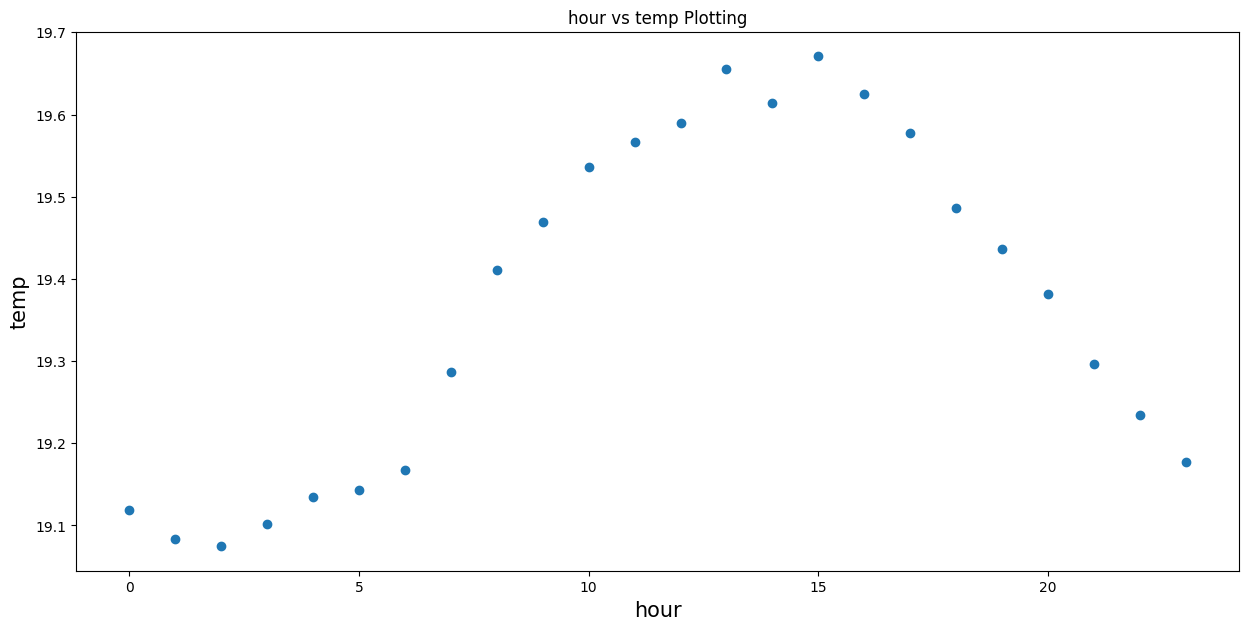

In [15]:
feature_x = 'hour'
feature_y = 'temp'
GroupByDF= data.loc[:,[feature_x,feature_y]].groupby(feature_x, as_index=False).mean()
display(GroupByDF)
plt.figure(figsize= (15,7))
plt.scatter(GroupByDF[feature_x],GroupByDF[feature_y])
plt.title(f"{feature_x} vs {feature_y} Plotting")
plt.xlabel(feature_x, size = 15)
plt.ylabel(feature_y, size=15)
plt.savefig(f"{feature_x} vs {feature_y} Plotting.jpg")
plt.show()

In [ ]:
GroupByDF1= data.loc[:,[feature_x,feature_y]]
GroupByDF1[feature_y]==28

0         False
1         False
2         False
3         False
4         False
          ...  
619994    False
619995    False
619996    False
619997    False
619998    False
Name: temp, Length: 619999, dtype: bool

,minute,temp
0,0,19.161731
1,1,19.153318
2,2,19.169683
3,3,19.152273
4,4,19.141230
...,...,...
1435,1435,19.178490
1436,1436,19.155606
1437,1437,19.157895
1438,1438,19.132118


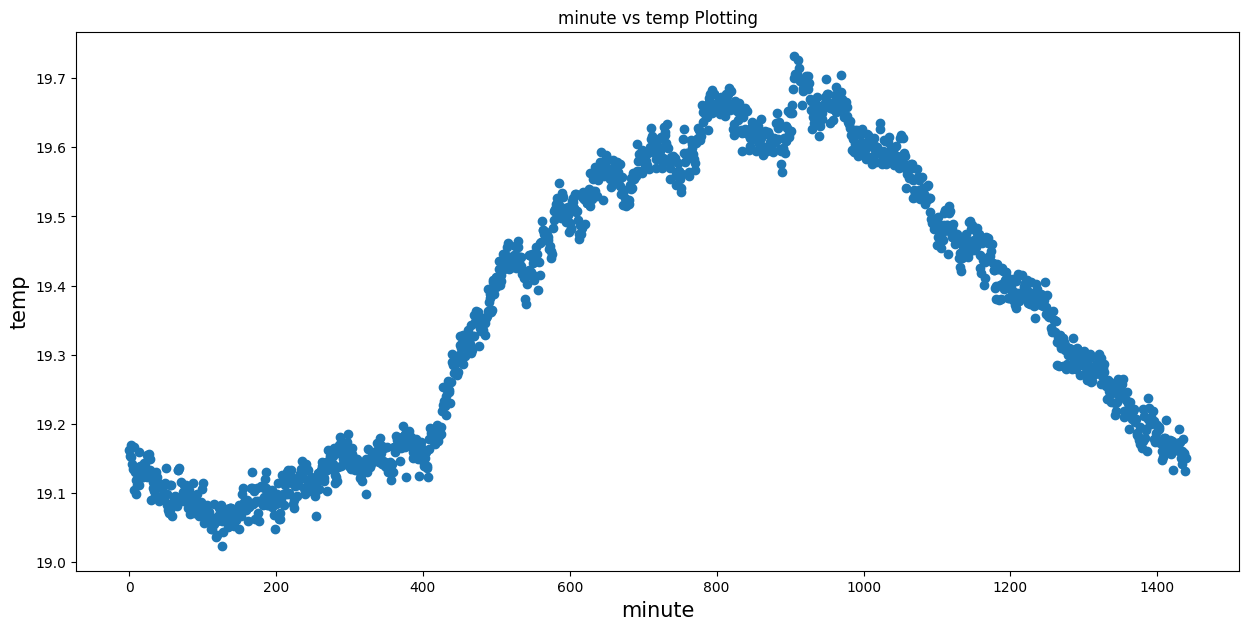

In [16]:
feature_x = 'minute'
feature_y = 'temp'
GroupByDF= data.loc[:,[feature_x,feature_y]].groupby(feature_x, as_index=False).mean()
display(GroupByDF)
plt.figure(figsize= (15,7))
plt.scatter(GroupByDF[feature_x],GroupByDF[feature_y])
plt.title(f"{feature_x} vs {feature_y} Plotting")
plt.xlabel(feature_x, size = 15)
plt.ylabel(feature_y, size=15)
plt.savefig(f"{feature_x} vs {feature_y} Plotting.jpg")
plt.show()

,month,temp
0,1,19.416576
1,2,20.486926
2,3,21.167560
3,4,18.424530
4,5,18.308455
5,6,18.431854
6,7,18.588544
7,8,19.970227
8,9,19.981010
9,10,19.687252


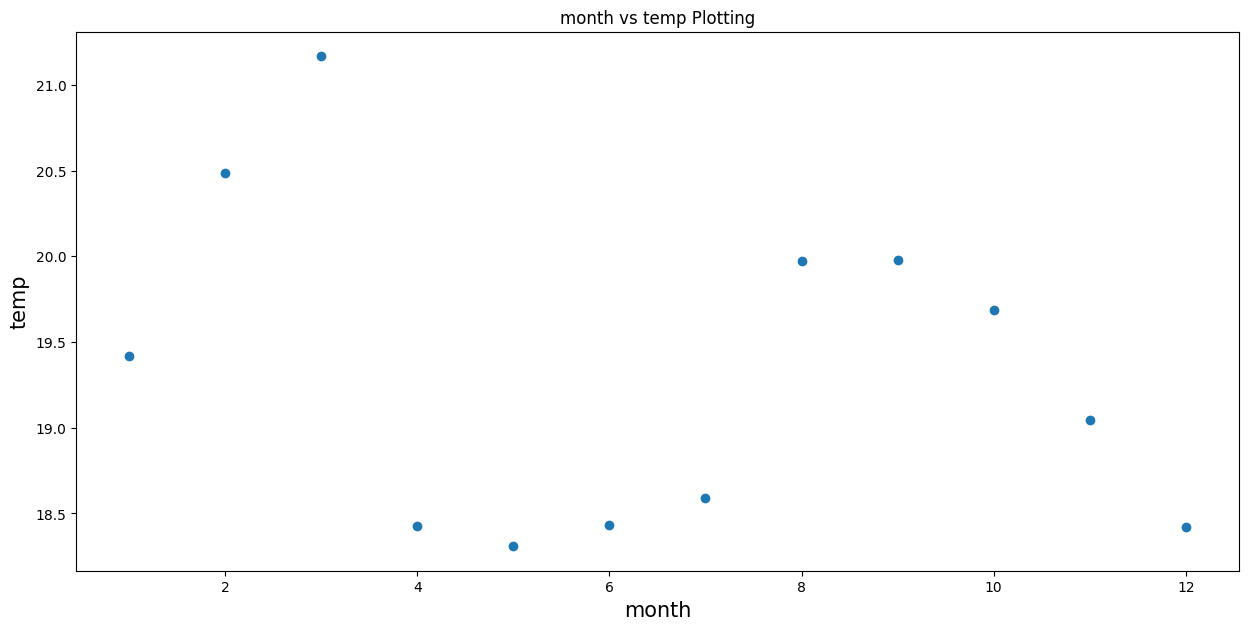

In [ ]:
feature_x = 'month'
feature_y = 'temp'
GroupByDF= data.loc[:,[feature_x,feature_y]].groupby(feature_x, as_index=False).mean()
display(GroupByDF)
plt.figure(figsize= (15,7))
plt.scatter(GroupByDF[feature_x],GroupByDF[feature_y])
plt.title(f"{feature_x} vs {feature_y} Plotting")
plt.xlabel(feature_x, size = 15)
plt.ylabel(feature_y, size=15)
plt.savefig(f"{feature_x} vs {feature_y} Plotting.jpg")
plt.show()

In [ ]:
data.head()

,temp,humidity,date_time,hour,minute,Date_Of_Week,month
0,21,20,2016-08-17 00:00:01,0,0,Wednesday,8
1,21,20,2016-08-17 00:01:01,0,1,Wednesday,8
2,21,20,2016-08-17 00:02:01,0,2,Wednesday,8
3,21,20,2016-08-17 00:03:01,0,3,Wednesday,8
4,21,20,2016-08-17 00:04:01,0,4,Wednesday,8


In [19]:
feature_x = 'minute'
feature_y = 'temp'
DataX= data.loc[:,[feature_x,feature_y]].groupby(feature_x, as_index=False).mean()
print(DataX.shape)
display(DataX.head())
m1 = DataX[[feature_x]].values
m2 = DataX[feature_y].values
print(m1)
print(m2)

(1440, 2)


,minute,temp
0,0,19.161731
1,1,19.153318
2,2,19.169683
3,3,19.152273
4,4,19.141230


[[   0]
 [   1]
 [   2]
 ...
 [1437]
 [1438]
 [1439]]
[19.16173121 19.15331808 19.16968326 ... 19.15789474 19.13211845
 19.15068493]


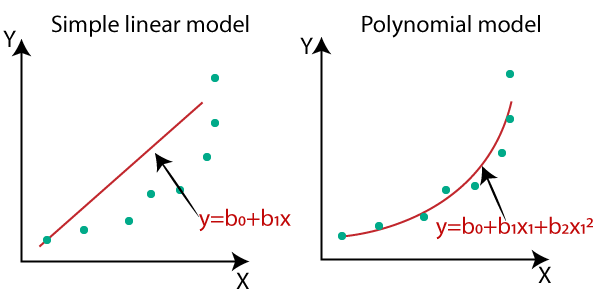

In [20]:
display(Image(filename='Polynomial Feature Model 01.png'))

In [32]:
# Polynomial model
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(m1)
print(X_poly.shape)
print(X_poly[:6])

(1440, 5)
[[  1.   0.   0.   0.   0.]
 [  1.   1.   1.   1.   1.]
 [  1.   2.   4.   8.  16.]
 [  1.   3.   9.  27.  81.]
 [  1.   4.  16.  64. 256.]
 [  1.   5.  25. 125. 625.]]


In [22]:
from sklearn.linear_model import LinearRegression
lin_reg= LinearRegression()
lin_reg.fit(X_poly, m2)

LinearRegression()

In [28]:
m2_predict=lin_reg.predict(poly_reg.fit_transform(m1))
m2_predict

array([19.19123175, 19.18928943, 19.1873632 , ..., 19.14239875,
       19.14153535, 19.14067664])

In [ ]:
m2

array([19.16173121, 19.15331808, 19.16968326, ..., 19.15789474,
       19.13211845, 19.15068493])

,minute,temp
0,0,19.161731
1,1,19.153318
2,2,19.169683
3,3,19.152273
4,4,19.141230
...,...,...
1435,1435,19.178490
1436,1436,19.155606
1437,1437,19.157895
1438,1438,19.132118


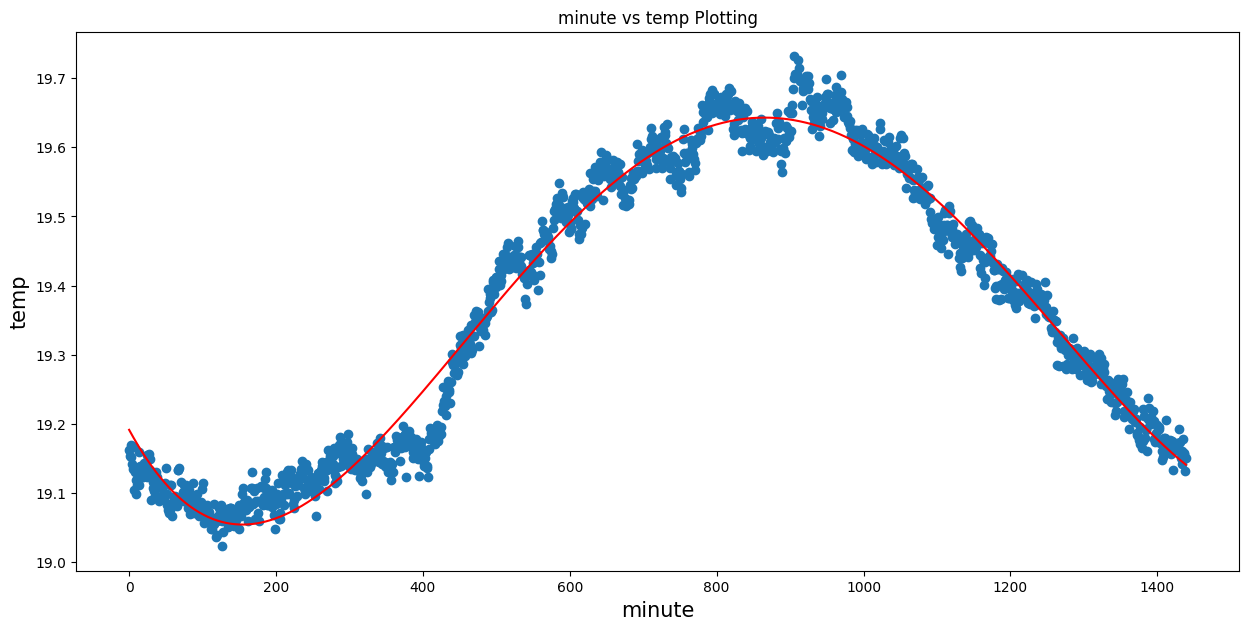

In [29]:
feature_x = 'minute'
feature_y = 'temp'
GroupByDF= data.loc[:,[feature_x,feature_y]].groupby(feature_x, as_index=False).mean()
display(GroupByDF)
plt.figure(figsize= (15,7))
plt.scatter(GroupByDF[feature_x],GroupByDF[feature_y])
plt.plot(m1,m2_predict, color = 'red')
plt.title(f"{feature_x} vs {feature_y} Plotting")
plt.xlabel(feature_x, size = 15)
plt.ylabel(feature_y, size=15)
plt.savefig(f"{feature_x} vs {feature_y} Plotting.jpg")
plt.show()

In [30]:
residuals = m2 - m2_predict
std = np.std(residuals)
m2_predict_up = m2_predict + 3*std
m2_predict_down = m2_predict - 3*std

,minute,temp
0,0,19.161731
1,1,19.153318
2,2,19.169683
3,3,19.152273
4,4,19.141230
...,...,...
1435,1435,19.178490
1436,1436,19.155606
1437,1437,19.157895
1438,1438,19.132118


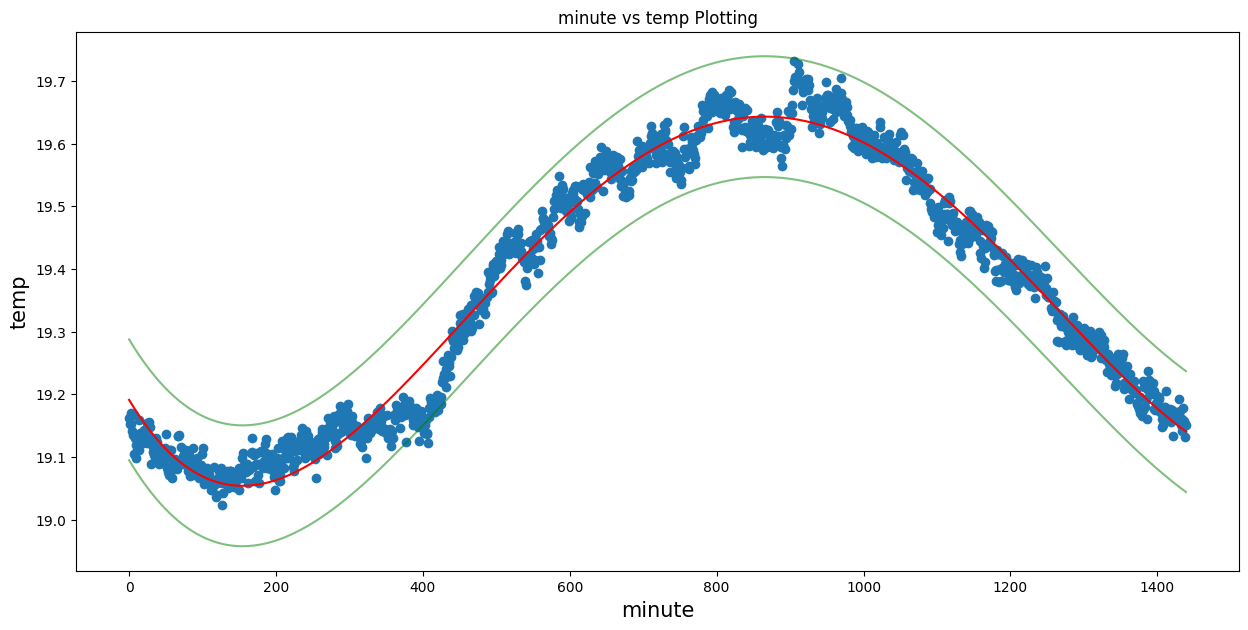

In [ ]:
feature_x = 'minute'
feature_y = 'temp'
GroupByDF= data.loc[:,[feature_x,feature_y]].groupby(feature_x, as_index=False).mean()
display(GroupByDF)
plt.figure(figsize= (15,7))
plt.scatter(GroupByDF[feature_x],GroupByDF[feature_y])
plt.plot(m1,m2_predict, color = 'red')
plt.plot(m1,m2_predict_up, color = 'green', alpha=0.5)
plt.plot(m1,m2_predict_down, color = 'green', alpha=0.5)
plt.title(f"{feature_x} vs {feature_y} Plotting")
plt.xlabel(feature_x, size = 15)
plt.ylabel(feature_y, size=15)
plt.savefig(f"{feature_x} vs {feature_y} Plotting.jpg")
plt.show()

In [ ]:
import random
number = random.randint(-100,101)
print(number)
print(f"Positive: {number>=0}")
print(f"Number of digits: {len(str(number)) if (number>=0) else len(str(number))-1}")

-59
Positive: False
Number of digits: 2
